2.12.0+cpu
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Using Device cpu
Epoch 1/5 | Loss: 317.6131 
Epoch 2/5 | Loss: 133.2593 
Epoch 3/5 | Loss: 91.8640 
Epoch 4/5 | Loss: 70.6994 
Epoch 5/5 | Loss: 52.3919 
 Total Accuracy: 97.29 
Model Saved as mnist_model.pth


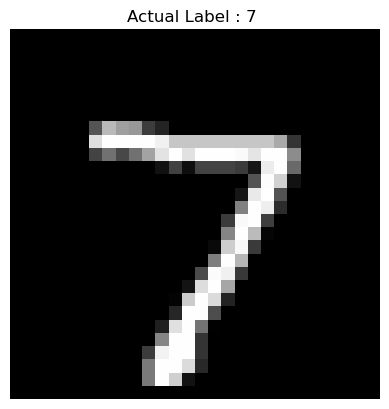

User picked image index 0
Actual Label: 7
Model Prediction: 7


In [13]:
import torch
print(torch.__version__)
import sys
print(sys.version)
import torch.nn as nn
import torch.optim as optim 
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device", device)

transform = transforms.ToTensor()

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64, 
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64, 
    shuffle=False
)

class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(28*28, 128), 
            nn.ReLU(),

            nn.Linear(128,64), 
            nn.ReLU(),
            
            nn.Linear(64,10)
        )

    def forward(self, x):
        return self.net(x)

model = DigitModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    model.train() 
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad() 
        outputs = model(images)
        loss = loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() 

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} ")
        
model.eval()
correct = 0 
total = 0 

with torch.no_grad(): 
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim = 1)

        correct += (predictions == labels).sum().item() 
        total += labels.size(0) 

accuracy = 100 * correct/total 
print(f" Total Accuracy: {accuracy:.2f} ")

torch.save(model.state_dict(), "mnist_model.pth" )
print("Model Saved as mnist_model.pth")

index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label : {true_label} ")
plt.axis("off")
plt.show() 

image_flat = image.view(1,-1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item() 

print("User picked image index", index) 
print("Actual Label:",true_label)
print("Model Prediction:", predicted_label)
    